# Installing necessary libraries

In [ ]:
!pip install torch_geometric
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.datasets import TUDataset
import networkx as nx
from tqdm import tqdm
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
import csv, time, random , gc

# Seed for reproducibility

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)   
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

# Loading Dataset

In [ ]:
print("Loading and preprocessing the dataset...")
dataset = TUDataset(root='/tmp/AIDS', name='AIDS', use_node_attr=True)

Loading and preprocessing the dataset...


Processing...
Done!


# Helper functions

## The wl_signature used here is exactly same as the one used in Task-7, the one given as template in this task was not used as it appended values at each iteration

### The one in this template seemed more appropraite for graph as document so it was not changed to accomodate to check for isomorphism rather the earlier task one was used

In [ ]:
def _wl_signature(G) :
    # seed from node attribute 'label' 
    colors = {n: G.nodes[n].get('label', 0) for n in G.nodes()}
    iters = 3
    for _ in range(iters):  # WL refinement
        new_colors = {}
        for n in G.nodes():
            neigh = sorted(colors[v] for v in G.neighbors(n))
            sig = (colors[n], tuple(neigh))
            new_colors[n] = hash(sig)
        if new_colors == colors:  # converged
            break
        colors = new_colors
    # canonical, order-free signature
    return tuple(sorted(colors.values()))

# Same logic as earlier, just in Task-7 it grouped in a dictionary based on wl keys obtained
# Here I modify it to return True or False by mathcing wl signatures

def is_isomorphic(g1, g2) :
    return _wl_signature(g1) == _wl_signature(g2)

## As all the graphs were being iterated over in this section, I defined the label here as 'betweeness centrality' ( Same as Task-7)


### This is further used for computing WL signature and checking isomorphism

In [ ]:
unique_graphs = []
unique_labels = []
seen_graphs = []

for i, data in enumerate(tqdm(dataset, desc="Removing isomorphic graphs")):
    # Convert PyG graph to NetworkX for isomorphism checks
    g = nx.Graph()
    # Add nodes and edges
    g.add_nodes_from(range(data.num_nodes))
    edges = data.edge_index.t().tolist()
    g.add_edges_from(edges)

    bc = nx.betweenness_centrality(g, normalized=False)   # raw counts
    bc_int = {u: int(round(bc[u])) for u in g.nodes()}    # make sure integer
    nx.set_node_attributes(g, bc_int, 'label')

    # Check if a structurally identical graph has already been seen
    is_new = True
    for seen_g in seen_graphs:
        if is_isomorphic(g, seen_g): #TODO: add the is_isomorphic function
       # to check whether g and seen_g are isomorphic or not. replace this function
       # with your TASK7 function (or modify your TASK7 function such that it returns
       # True/False for two graph as parameter in case it is not currently)
       # A skeliton is provided in line 75
            is_new = False
            break

    if is_new:
        unique_graphs.append(g)
        unique_labels.append(data.y.item())
        seen_graphs.append(g)

Removing isomorphic graphs: 100%|██████████| 2000/2000 [01:59<00:00, 16.71it/s]


In [ ]:
print(f"\nOriginal graphs: {len(dataset)}")
print(f"Unique graphs (after removing isomorphisms): {len(unique_graphs)}")
labels_np = np.array(unique_labels)
print(np.unique(labels_np))


Original graphs: 2000
Unique graphs (after removing isomorphisms): 1178
[0 1]


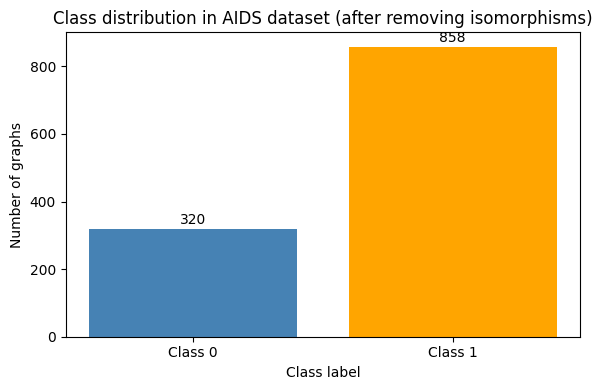

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Count occurrences of each class
unique, counts = np.unique(labels_np, return_counts=True)

# Plot bar chart
plt.figure(figsize=(6,4))
bars = plt.bar(unique, counts, tick_label=[f"Class {u}" for u in unique], color=["steelblue","orange"])
plt.xlabel("Class label")
plt.ylabel("Number of graphs")
plt.title("Class distribution in AIDS dataset (after removing isomorphisms)")

# Annotate counts on top of bars
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(c),
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


## WL Kernel as given in the template

In [ ]:
def wl_kernel_labeling(graph, iterations=2):
    """
    Applies the Weisfeiler-Lehman (WL) kernel labeling.
    This generates a canonical representation of subgraphs to be used
    as 'words' for Doc2Vec.
    """
    current_labels = {node: str(graph.degree(node)) for node in graph.nodes()}
    all_labels = []

    for _ in range(iterations):
        new_labels = {}
        for node in graph.nodes():
            neighbor_labels = sorted([current_labels[neighbor] for neighbor in graph.neighbors(node)])
            new_label = current_labels[node] + "".join(neighbor_labels)
            new_labels[node] = new_label

        # Hash new labels to get a consistent representation
        label_mapping = {label: i for i, label in enumerate(sorted(set(new_labels.values())))}
        current_labels = {node: str(label_mapping[new_labels[node]]) for node in graph.nodes()}
        all_labels.extend(list(current_labels.values()))

    return all_labels

## Creation of graph documents using WL signatures

In [ ]:
documents = []
for i, g in enumerate(tqdm(unique_graphs, desc="Creating graph documents")):
    labels = wl_kernel_labeling(g, iterations=3)
    documents.append(TaggedDocument(labels, [i]))

Creating graph documents: 100%|██████████| 1178/1178 [00:00<00:00, 14629.62it/s]


## Doc2Vec : Takes each document (graph) and then converts it to an embedding of desired size

In [ ]:
def train_doc2vec(documents, dim=128, epochs=10, seed=42):
    model = Doc2Vec(documents,vector_size=dim,window=5, min_count=1,epochs=epochs, seed=seed, workers=4)
    emb = np.array([model.dv[i] for i in range(len(documents))])
    print(f"Generated embeddings with dimension: {dim}")
    return emb


## Simple classifier taking graph embeddings and classifying graph into one of the two labels [0,1]

In [ ]:
class GraphClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GraphClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## Converted the same template code into a function to remove redundancy and use it in loops

### **Note** : Added classwise metrics as well, this aids in analysis

In [ ]:
def evaluate_embeddings(embeddings, labels, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, random_state=seed, stratify=labels
    )
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=32)

    model = GraphClassifier(input_dim=embeddings.shape[1], hidden_dim=64, output_dim=len(set(labels)))
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for _ in range(50):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()

    model.eval(); preds=[]; gts=[]
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy()); gts.extend(yb.cpu().numpy())

    # --- overall (macro) ---
    acc        = accuracy_score(gts, preds)
    prec_macro = precision_score(gts, preds, average="macro", zero_division=0)
    rec_macro  = recall_score(gts, preds, average="macro", zero_division=0)
    f1_macro   = f1_score(gts, preds, average="macro", zero_division=0)

    # --- per-class (0 = inactive, 1 = active) ---
    prec_c = precision_score(gts, preds, average=None, labels=[0,1], zero_division=0)
    rec_c  = recall_score(gts, preds, average=None, labels=[0,1], zero_division=0)
    f1_c   = f1_score(gts, preds, average=None, labels=[0,1], zero_division=0)

    # --- confusion matrix ---
    tn, fp, fn, tp = confusion_matrix(gts, preds, labels=[0,1]).ravel()

    return (acc, prec_macro, rec_macro, f1_macro,
            prec_c[0], rec_c[0], f1_c[0],
            prec_c[1], rec_c[1], f1_c[1],
            tn, fp, fn, tp)

## Experiment for the varying embedding dimensions for documents using WL signatures

In [ ]:
# ---------- (A) WL: sweep embedding dimensions ----------
dims = [2**k for k in range(4, 11)]  # 16..1024
rows = []
for d in dims:
    t0 = time.time()
    emb = train_doc2vec(documents, dim=d, epochs=10, seed=42)
    (acc, prec_macro, rec_macro, f1_macro,
     prec_c0, rec_c0, f1_c0,
     prec_c1, rec_c1, f1_c1,
     tn, fp, fn, tp) = evaluate_embeddings(emb, labels_np, seed=42)

    rows.append(["WL", d, None, None,
                 acc, prec_macro, rec_macro, f1_macro,
                 prec_c0, rec_c0, f1_c0,
                 prec_c1, rec_c1, f1_c1,
                 tn, fp, fn, tp,
                 time.time()-t0])

with open("results_wl_dims.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["method","dim","walk_len","num_walks",
                "acc","prec_macro","rec_macro","f1_macro",
                "prec_c0","rec_c0","f1_c0",
                "prec_c1","rec_c1","f1_c1",
                "tn","fp","fn","tp","sec"])
    w.writerows(rows)
print("wrote results_wl_dims.csv")


Generated embeddings with dimension: 16
Generated embeddings with dimension: 32
Generated embeddings with dimension: 64
Generated embeddings with dimension: 128
Generated embeddings with dimension: 256
Generated embeddings with dimension: 512
Generated embeddings with dimension: 1024
wrote results_wl_dims.csv


## Code for generating anonymous walks based on definition in docstring given in template

In [ ]:
def generate_anonymous_walks(graph, walk_length=5, num_walks=10):
    """
    Generates a set of anonymous random walks for a given graph.

    Each anonymous walk is a sequence of integers where each integer represents
    the number of times a node has been visited so far in the walk.
    """
    all_walks = []
    nodes = list(graph.nodes())
    if not nodes:
        return []

    for _ in range(num_walks):
        # Start walk from a random node
        current_node = random.choice(nodes)
        walk_path = [current_node]

        # Track visit count for each node in this specific walk
        visit_counts = {current_node: 1}
        anonymous_walk = [1] # The first node is always visited once

        #TODO: Write the code for the anonymous walk here.
        for _ in range(walk_length):
            nbrs = list(graph.neighbors(current_node))
            if not nbrs:
                break
            nxt = random.choice(nbrs)
            walk_path.append(nxt)
            visit_counts[nxt] = visit_counts.get(nxt, 0) + 1
            anonymous_walk.append(visit_counts[nxt])
            current_node = nxt
        # Convert the anonymous walk to a string for Doc2Vec
        all_walks.append([str(val) for val in anonymous_walk])

    return all_walks

## Code for building documents using anonymous walks

### Each token is a walk of defined lenght and the number of tokens are baed on number of walks

In [ ]:
#  Anonymous Walks: build documents per config 
def build_aw_documents(graphs, walk_length=5, num_walks=100):
    documents_aw = []
    for i, g in enumerate(graphs):
        # Each walk is a "sentence" = list[str]; Doc2Vec expects flat words, so flatten
        walk_sentences = generate_anonymous_walks(g, walk_length=walk_length, num_walks=num_walks)
        labels = [tok for sent in walk_sentences for tok in sent]  # flatten to tokens
        documents_aw.append(TaggedDocument(labels, [i]))
    return documents_aw

## Experiment for changing walk lenght from 5-105 with step 10. By default the number of walks is kept to 100 . Embedding dimension is 128

In [ ]:
#  (B) AW: sweep walk_length (5..105 step 10), dim=128 
rows = []
for L in range(5, 106, 10):
    t0 = time.time()
    documents_aw = build_aw_documents(unique_graphs, walk_length=L, num_walks=100)
    emb = train_doc2vec(documents_aw, dim=128, epochs=10, seed=42)
    (acc, prec_macro, rec_macro, f1_macro,
     prec_c0, rec_c0, f1_c0,
     prec_c1, rec_c1, f1_c1,
     tn, fp, fn, tp) = evaluate_embeddings(emb, labels_np, seed=42)

    rows.append(["AW_len", 128, L, 100,
                 acc, prec_macro, rec_macro, f1_macro,
                 prec_c0, rec_c0, f1_c0,
                 prec_c1, rec_c1, f1_c1,
                 tn, fp, fn, tp,
                 time.time() - t0])

with open("results_aw_lengths.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["method","dim","walk_len","num_walks",
                "acc","prec_macro","rec_macro","f1_macro",
                "prec_c0","rec_c0","f1_c0",
                "prec_c1","rec_c1","f1_c1",
                "tn","fp","fn","tp","sec"])
    w.writerows(rows)
print("wrote results_aw_lengths.csv")


Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
wrote results_aw_lengths.csv


## Experiment for varying the number of walks from 10-1010 with step 100, the walk length is fixed to 5 . Embedding dimension is 128

In [ ]:
#  (C) AW: sweep num_walks (10..1010 step 100), walk_length fixed 
rows = []
FIXED_L = 5
for M in range(10, 1011, 100):
    t0 = time.time()
    documents_aw = build_aw_documents(unique_graphs, walk_length=FIXED_L, num_walks=M)
    emb = train_doc2vec(documents_aw, dim=128, epochs=10, seed=42)
    (acc, prec_macro, rec_macro, f1_macro,
     prec_c0, rec_c0, f1_c0,
     prec_c1, rec_c1, f1_c1,
     tn, fp, fn, tp) = evaluate_embeddings(emb, labels_np, seed=42)

    rows.append(["AW_walks", 128, FIXED_L, M,
                 acc, prec_macro, rec_macro, f1_macro,
                 prec_c0, rec_c0, f1_c0,
                 prec_c1, rec_c1, f1_c1,
                 tn, fp, fn, tp,
                 time.time() - t0])

with open("results_aw_numwalks.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["method","dim","walk_len","num_walks",
                "acc","prec_macro","rec_macro","f1_macro",
                "prec_c0","rec_c0","f1_c0",
                "prec_c1","rec_c1","f1_c1",
                "tn","fp","fn","tp","sec"])
    w.writerows(rows)
print("wrote results_aw_numwalks.csv")


Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
wrote results_aw_numwalks.csv


## Plots

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt


### Line-chart for varying embedding dimension for WL documents

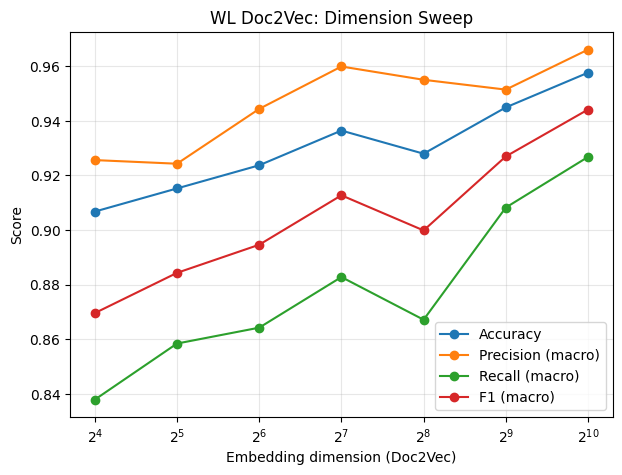

In [ ]:
df = pd.read_csv("results_wl_dims.csv")
df = df.sort_values("dim")
plt.figure(figsize=(7,5))
plt.plot(df["dim"], df["acc"], marker="o", label="Accuracy")
plt.plot(df["dim"], df["prec_macro"], marker="o", label="Precision (macro)")
plt.plot(df["dim"], df["rec_macro"], marker="o", label="Recall (macro)")
plt.plot(df["dim"], df["f1_macro"], marker="o", label="F1 (macro)")
plt.xscale("log", base=2)
plt.xlabel("Embedding dimension (Doc2Vec)")
plt.ylabel("Score")
plt.title("WL Doc2Vec: Dimension Sweep")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()


### Line chart for varying walk lengths for Anonymous walk documents

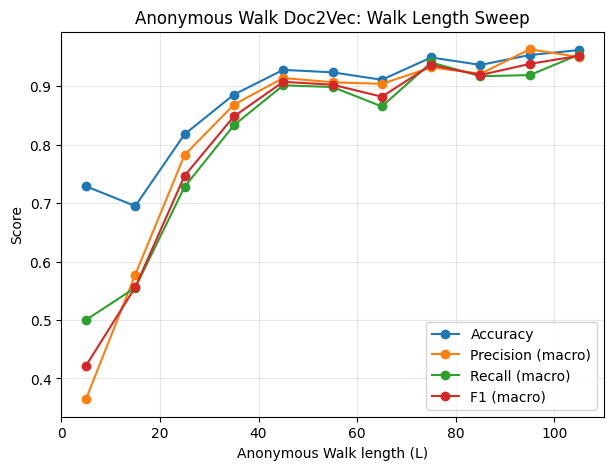

In [ ]:
df = pd.read_csv("results_aw_lengths.csv")
df = df.sort_values("walk_len")
plt.figure(figsize=(7,5))
plt.plot(df["walk_len"], df["acc"], marker="o", label="Accuracy")
plt.plot(df["walk_len"], df["prec_macro"], marker="o", label="Precision (macro)")
plt.plot(df["walk_len"], df["rec_macro"], marker="o", label="Recall (macro)")
plt.plot(df["walk_len"], df["f1_macro"], marker="o", label="F1 (macro)")
plt.xlabel("Anonymous Walk length (L)")
plt.ylabel("Score")
plt.title("Anonymous Walk Doc2Vec: Walk Length Sweep")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()


### Line chart for varying number of walks for Anonymous Walks documents

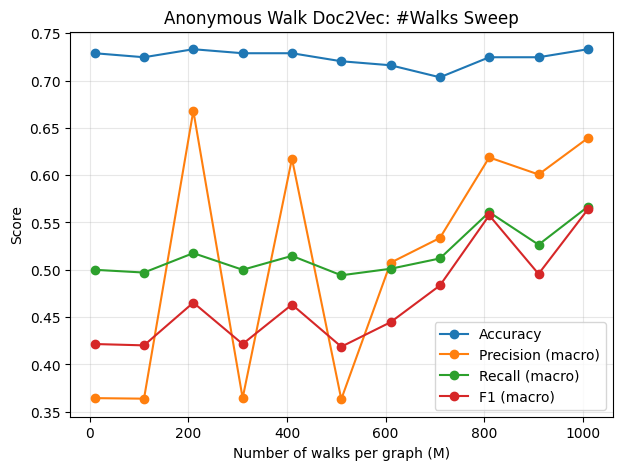

In [ ]:
df = pd.read_csv("results_aw_numwalks.csv")
df = df.sort_values("num_walks")
plt.figure(figsize=(7,5))
plt.plot(df["num_walks"], df["acc"], marker="o", label="Accuracy")
plt.plot(df["num_walks"], df["prec_macro"], marker="o", label="Precision (macro)")
plt.plot(df["num_walks"], df["rec_macro"], marker="o", label="Recall (macro)")
plt.plot(df["num_walks"], df["f1_macro"], marker="o", label="F1 (macro)")
plt.xlabel("Number of walks per graph (M)")
plt.ylabel("Score")
plt.title("Anonymous Walk Doc2Vec: #Walks Sweep")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()


### A comparison between results obatined by using WL vs Anonymous Walks for documents

#### Takes best value from the WL csv file. Takes best values from the varying walk lenght and varying number of walks and takes the best among them and plots it

#### Anonymous walk length (L) , Number of walks per graph (M). Best results obtained for L = 105 and M = 100

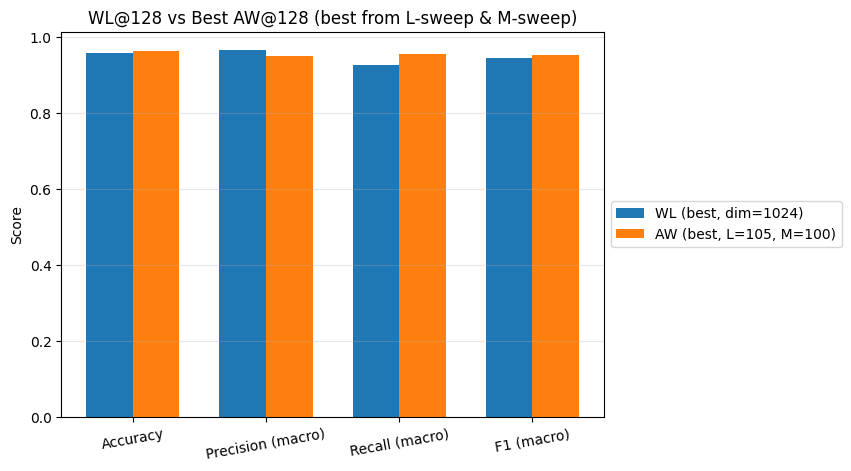

In [ ]:
# --- WL@128 ---
wl = pd.read_csv("results_wl_dims.csv")
# --- WL best overall from sweep ---
wl_best = wl.sort_values("f1_macro", ascending=False).head(1).iloc[0]
wl_vals = [wl_best["acc"], wl_best["prec_macro"], wl_best["rec_macro"], wl_best["f1_macro"]]


# --- AW best from each 1-D sweep ---
aw_len = pd.read_csv("results_aw_lengths.csv").sort_values("f1_macro", ascending=False).head(1).iloc[0]   # (var L, fixed M=100)
aw_m   = pd.read_csv("results_aw_numwalks.csv").sort_values("f1_macro", ascending=False).head(1).iloc[0]   # (var M, fixed L=5)

# pick the best-of-best AW
best_aw = aw_len if aw_len["f1_macro"] >= aw_m["f1_macro"] else aw_m
aw_vals = [best_aw["acc"], best_aw["prec_macro"], best_aw["rec_macro"], best_aw["f1_macro"]]

# --- plot ---
metrics = ["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)"]
x = np.arange(len(metrics)); w = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - w/2, wl_vals, width=w, label=f"WL (best, dim={int(wl_best['dim'])})")
plt.bar(x + w/2, aw_vals, width=w,
        label=f"AW (best, L={int(best_aw['walk_len'])}, M={int(best_aw['num_walks'])})")
plt.xticks(x, metrics, rotation=10)
plt.ylabel("Score")
plt.title("WL@128 vs Best AW@128 (best from L-sweep & M-sweep)")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


### Classwise metrics for L = 105 and M = 100

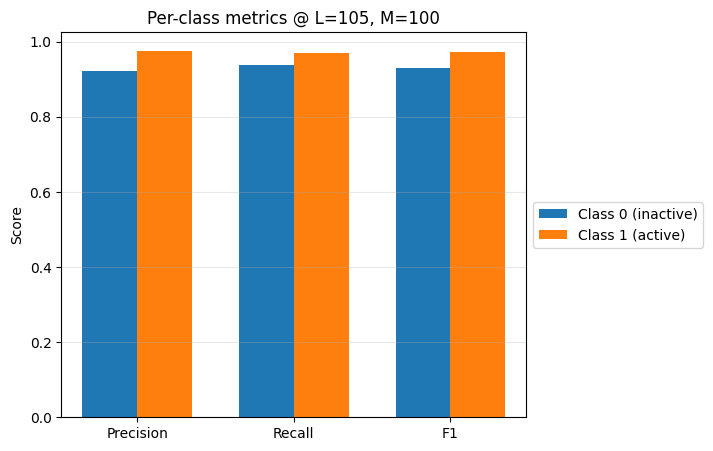

In [ ]:
# Pick the best row from any file (e.g., highest f1_macro in AW lengths)
df = pd.read_csv("results_aw_lengths.csv")
best = df.iloc[df["f1_macro"].to_numpy().argmax()]

c0 = [best["prec_c0"], best["rec_c0"], best["f1_c0"]]
c1 = [best["prec_c1"], best["rec_c1"], best["f1_c1"]]
labels = ["Precision", "Recall", "F1"]

x = np.arange(len(labels)); w = 0.35
plt.figure(figsize=(6,5))
plt.bar(x - w/2, c0, width=w, label="Class 0 (inactive)")
plt.bar(x + w/2, c1, width=w, label="Class 1 (active)")
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title(f"Per-class metrics @ L={int(best['walk_len'])}, M={int(best['num_walks'])}")
plt.grid(True, axis="y", alpha=0.3);
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


### Confusion matrix for L = 105 and M = 100

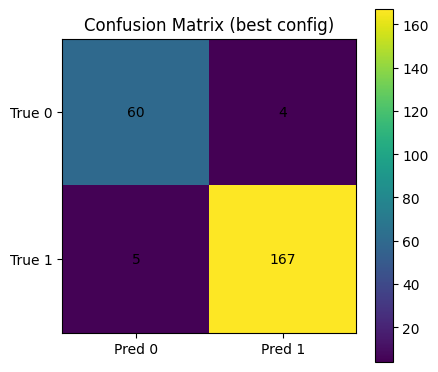

In [ ]:
tn, fp, fn, tp = int(best["tn"]), int(best["fp"]), int(best["fn"]), int(best["tp"])
cm = np.array([[tn, fp],[fn, tp]])

plt.figure(figsize=(4.5,4))
plt.imshow(cm, aspect="equal", origin="upper")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
plt.title("Confusion Matrix (best config)")
plt.colorbar()
plt.tight_layout()
plt.show()


### Defining function to plot classwise metrics for all the experiments

In [5]:
import pandas as pd, matplotlib.pyplot as plt

def plot_classwise(df, xcol, title):
    """
    df   : DataFrame with per-class metrics (prec_c0/1, rec_c0/1, f1_c0/1) and 'acc'
    xcol : column to use for x-axis (e.g., 'walk_len', 'num_walks', or 'dim')
    title: figure title
    """
    x = df[xcol]

    fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)
    axes = axes.ravel()

    # --- F1 ---
    axes[0].plot(x, df["f1_c0"], marker="o", label="Class 0 (inactive)")
    axes[0].plot(x, df["f1_c1"], marker="o", label="Class 1 (active)")
    axes[0].set_title("F1 per class"); axes[0].set_ylabel("F1")
    axes[0].grid(alpha=0.3); axes[0].legend()

    # --- Precision ---
    axes[1].plot(x, df["prec_c0"], marker="o", label="Class 0")
    axes[1].plot(x, df["prec_c1"], marker="o", label="Class 1")
    axes[1].set_title("Precision per class")
    axes[1].grid(alpha=0.3); axes[1].legend()

    # --- Recall ---
    axes[2].plot(x, df["rec_c0"], marker="o", label="Class 0")
    axes[2].plot(x, df["rec_c1"], marker="o", label="Class 1")
    axes[2].set_title("Recall per class"); axes[2].set_xlabel(xcol); axes[2].set_ylabel("Recall")
    axes[2].grid(alpha=0.3); axes[2].legend()

    # --- Class disparity (ΔF1) ---
    gap = df["f1_c1"] - df["f1_c0"]
    axes[3].plot(x, gap, marker="o", color="purple")
    axes[3].axhline(0, linestyle="--", color="black", linewidth=1)
    axes[3].set_title("ΔF1 = Class1 − Class0"); axes[3].set_xlabel(xcol)
    axes[3].set_ylabel("ΔF1"); axes[3].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()


### Metrics for varying walk length

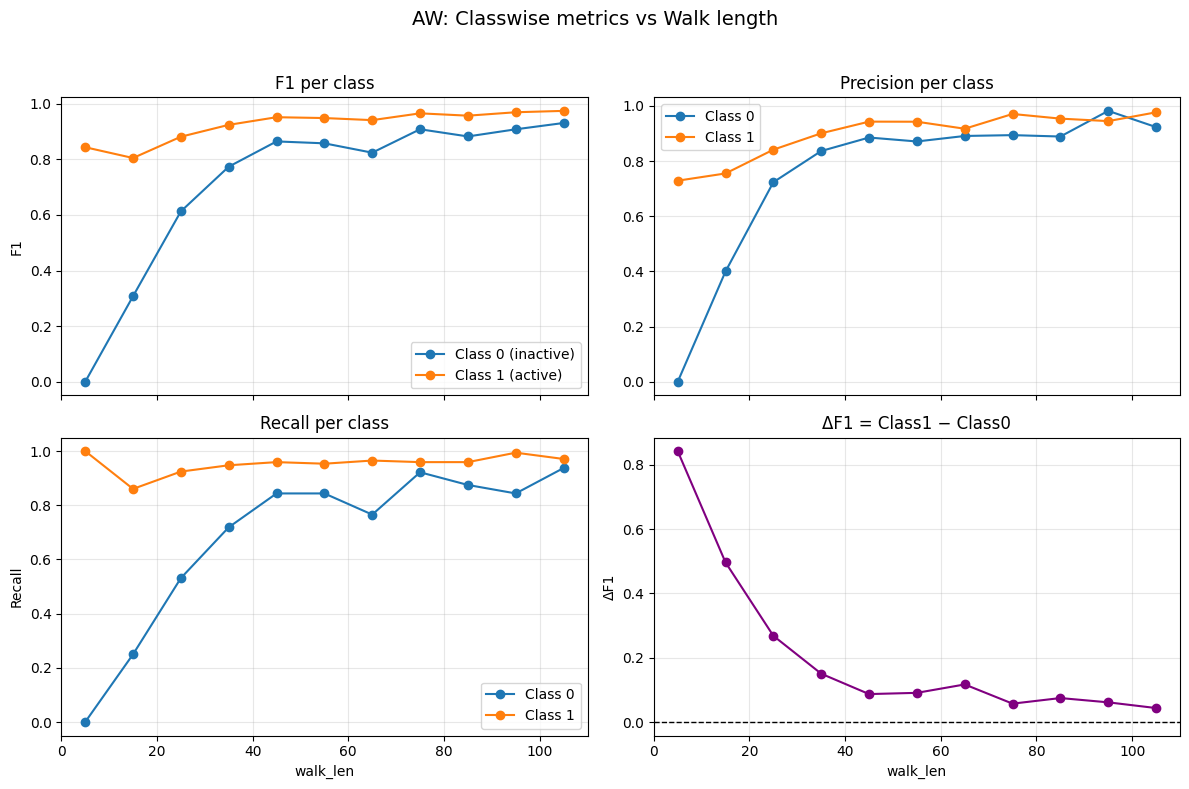

In [6]:
df = pd.read_csv("results_aw_lengths.csv").sort_values("walk_len")
plot_classwise(df, "walk_len", "AW: Classwise metrics vs Walk length")


### Experiments for varying number of walks

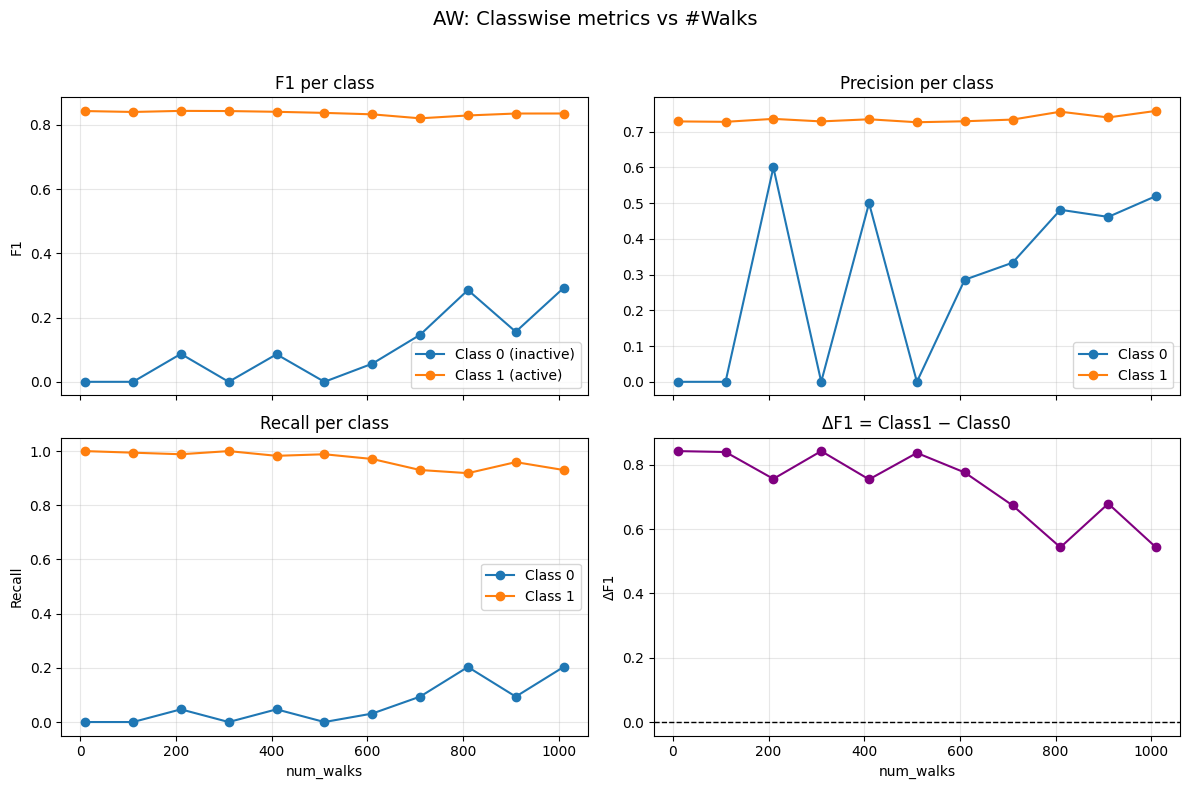

In [7]:
df = pd.read_csv("results_aw_numwalks.csv").sort_values("num_walks")
plot_classwise(df, "num_walks", "AW: Classwise metrics vs #Walks")


### Experiments for varying embedding dimension

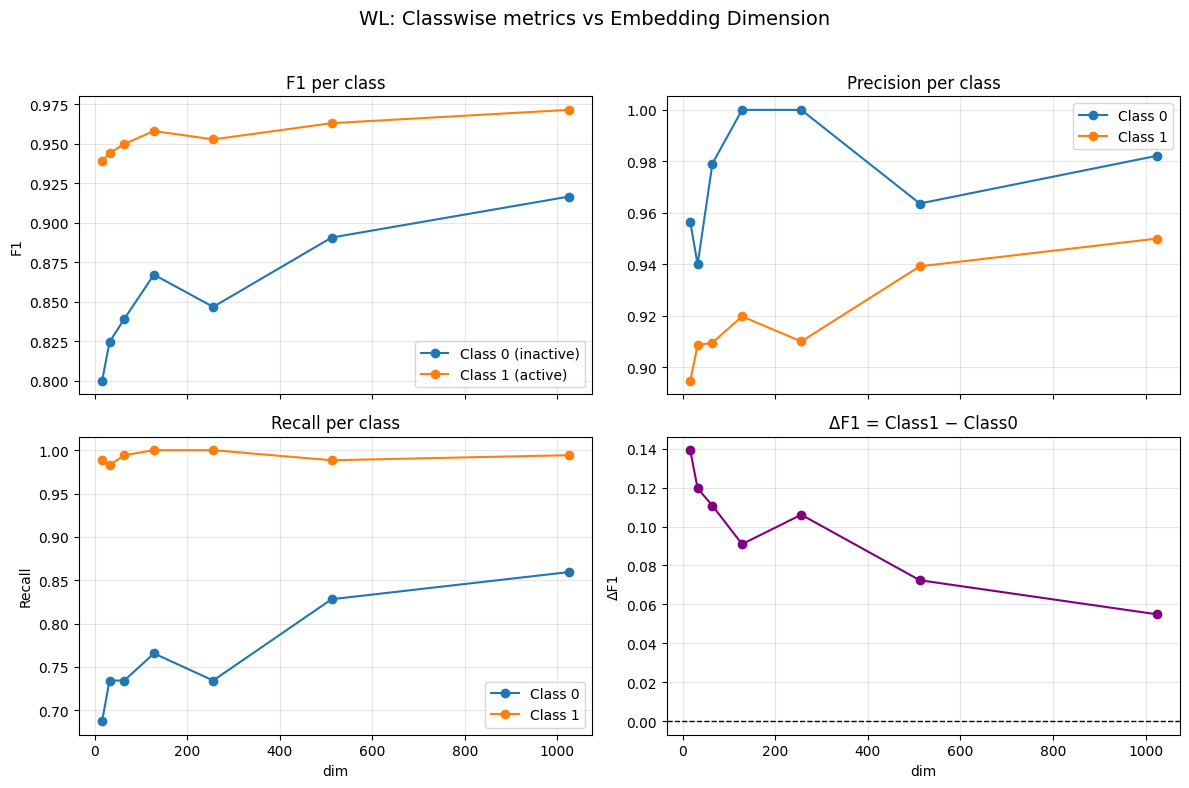

In [11]:
df = pd.read_csv("results_wl_dims.csv").sort_values("dim")
plot_classwise(df, "dim", "WL: Classwise metrics vs Embedding Dimension")


### A grid search for checking which L and M value gives the best results . Different from earlier, as in those one of the values was fixed either L = 5 or M = 100

In [ ]:
Ls = list(range(5, 106, 20))     # 5,25,45,65,85,105
Ms = list(range(10, 1011, 200))  # 10,210,410,610,810,1010

best = None
best_f1 = -1.0

with open("results_aw_grid.csv","w",newline="") as f:
    w = csv.writer(f)
    w.writerow(["method","dim","walk_len","num_walks",
                "acc","prec_macro","rec_macro","f1_macro",
                "prec_c0","rec_c0","f1_c0",
                "prec_c1","rec_c1","f1_c1",
                "tn","fp","fn","tp","sec"])

    for L in Ls:
        for M in Ms:
            t0 = time.time()
            docs = build_aw_documents(unique_graphs, walk_length=L, num_walks=M)
            emb  = train_doc2vec(docs, dim=128, epochs=8, seed=42)
            (acc, prec_macro, rec_macro, f1_macro,
             prec_c0, rec_c0, f1_c0,
             prec_c1, rec_c1, f1_c1,
             tn, fp, fn, tp) = evaluate_embeddings(emb, labels_np)

            w.writerow(["AW_grid", 128, L, M,
                        acc, prec_macro, rec_macro, f1_macro,
                        prec_c0, rec_c0, f1_c0,
                        prec_c1, rec_c1, f1_c1,
                        tn, fp, fn, tp,
                        time.time()-t0])

            if f1_macro > best_f1:
                best_f1 = f1_macro
                best = (L, M, acc, prec_macro, rec_macro, f1_macro)

            # free memory for the next iteration
            del docs, emb
            gc.collect()

print("Grid search done → results_aw_grid.csv")
print(f"Best coarse config: L={best[0]}, M={best[1]}, "
      f"Acc={best[2]:.3f}, Prec={best[3]:.3f}, Rec={best[4]:.3f}, F1={best[5]:.3f}")

Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embeddings with dimension: 128
Generated embedd